In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from src.lbp import *
from src.utilities import *

In [3]:
img = np.array(Image.open('Data/DTD/test/veined/01703.png').convert('L')).astype(np.int16)

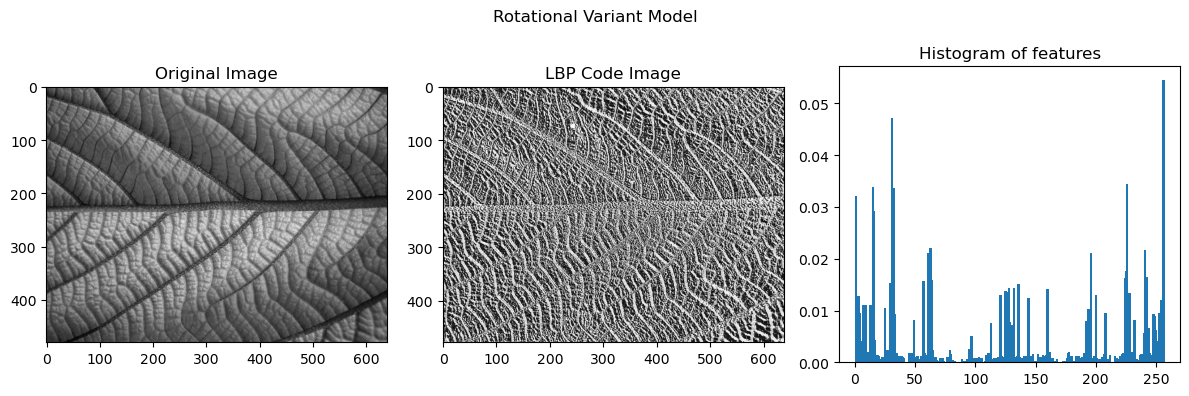

Number of Features: 256


In [4]:
# Generate LBP
hist, lbp_map = compute_lbp_features(img)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original Image")
axes[1].imshow(lbp_map, cmap='gray')
axes[1].set_title("LBP Code Image")
axes[2].bar(np.arange(0, 256), hist, width=2, align='edge')
axes[2].set_title("Histogram of features")
fig.suptitle("Rotational Variant Model")
plt.tight_layout()
plt.show()

print(f"Number of Features: {np.sum(hist != 0)}")

#### Q1.a) Apply LBP feature extraction and perform 1NN Texture Classification

In [5]:
# Load Full Data
X_train, X_test, y_train, y_test = load_train_test_data(train_path='Data/DTD/train/', test_path='Data/DTD/test/')

Loading Test Images: 100%|██████████| 47/47 [00:11<00:00,  4.20it/s, Current Class=zigzagged]   


In [9]:
# Using all 47 classes
simple_model = LBP()
simple_model.fit(X_train, y_train)
simple_model.predict(X_test, y_test)

acc = getAccuracy(simple_model.y_pred, simple_model.y_test)
print(f"Classification Accuracy:  {acc * 100:.2f}%")

Extracting Test Features: 100%|██████████| 1880/1880 [00:09<00:00, 200.20it/s]


Classification Accuracy:  13.78%


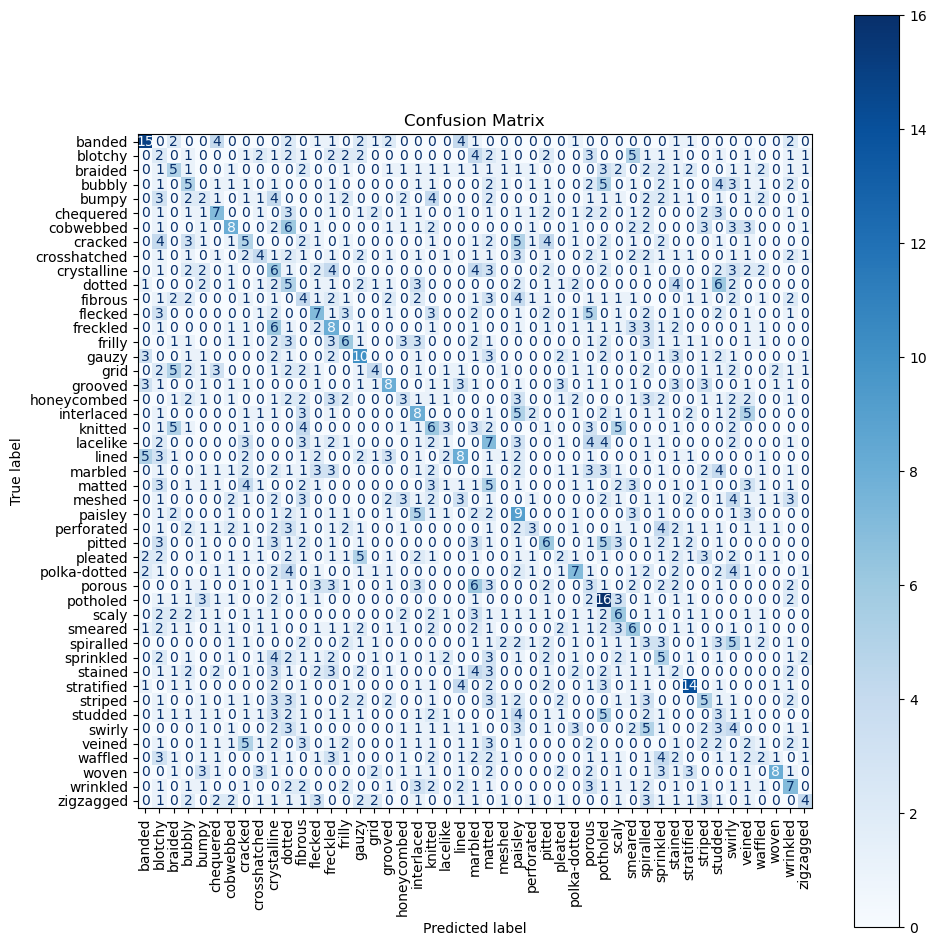

In [10]:
createConfusionMatrix(simple_model.y_pred, simple_model.y_test)

In [25]:
# Accuracy seems low but it is not, because the number of classes are too high, that is, 47. 
# A blind model will give 1/47 = 2.1% accuracy. 
# It means the model is able to learn something from the LBP features. 
# It can also be seen from the confusion matrix that the diagonal values are higher than the
# non-diagonals

#### Q1.b) Apply LBP feature extraction on rotated Images and perform 1NN Texture Classification

In [17]:
rotate_angles = [0, 30, 45, 60, 90, 120, 135, 150, 180]
SM_accuracy_list = {}
SM_model_list = {}

In [18]:
for angle in rotate_angles:
    print(f"Rotate Angle: {angle} deg")
    X_train, X_test, y_train, y_test = load_train_test_data(train_path='Data/DTD/train/', test_path='Data/DTD/test/', train_rotate_angle=0, test_rotate_angle=angle)
    model = LBP()
    model.fit(X_train, y_train)
    model.predict(X_test, y_test)
    SM_model_list[angle] = model
    acc = getAccuracy(model.y_pred, model.y_test)
    SM_accuracy_list[angle] = acc * 100
    print(f"Classification Accuracy: {acc*100:.2f}%")
    print('-'*60)

Rotate Angle: 0 deg


Extracting Test Features: 100%|██████████| 1880/1880 [00:15<00:00, 124.71it/s]


Classification Accuracy: 13.78%
------------------------------------------------------------
Rotate Angle: 30 deg


Extracting Test Features: 100%|██████████| 1880/1880 [00:15<00:00, 117.82it/s]


Classification Accuracy: 4.31%
------------------------------------------------------------
Rotate Angle: 45 deg


...

Classification Accuracy: 2.02%
------------------------------------------------------------
Rotate Angle: 150 deg


Extracting Test Features: 100%|██████████| 1880/1880 [00:15<00:00, 119.81it/s]


Classification Accuracy: 3.19%
------------------------------------------------------------
Rotate Angle: 180 deg


Extracting Test Features: 100%|██████████| 1880/1880 [00:14<00:00, 126.34it/s]


Classification Accuracy: 12.13%
------------------------------------------------------------


#### Q1.c) Apply rotation invariant LBP feature extraction on rotated Images and perform 1NN Texture Classification

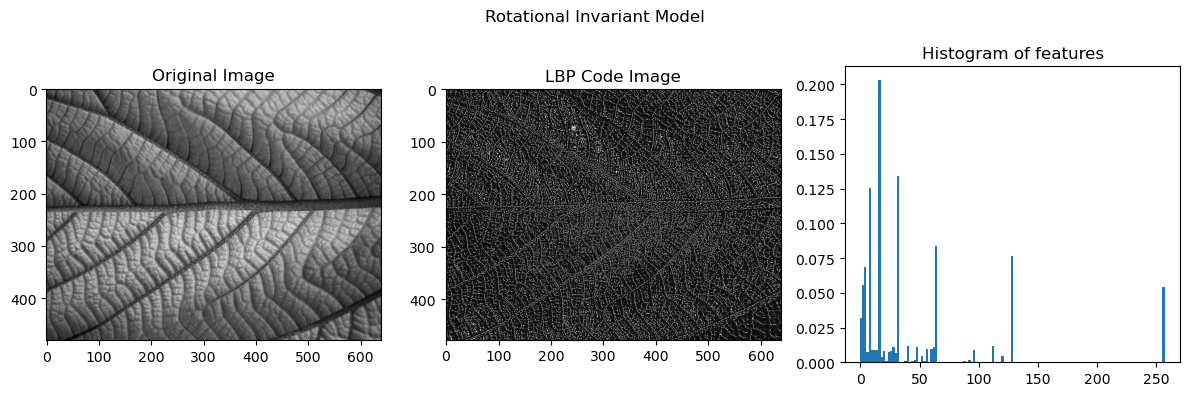

Number of Features: 36


In [19]:
# Generate LBP
rot_hist, rot_lbp_map = compute_lbp_features(img, rotation_invariant=True)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original Image")
axes[1].imshow(rot_lbp_map, cmap='gray')
axes[1].set_title("LBP Code Image")
axes[2].bar(np.arange(0, 256), rot_hist, width=2, align='edge')
axes[2].set_title("Histogram of features")
fig.suptitle("Rotational Invariant Model")
plt.tight_layout()
plt.show()

print(f"Number of Features: {np.sum(rot_hist != 0)}")

In [20]:
# Load Full Data with rotated Images
X_train, X_test, y_train, y_test = load_train_test_data(train_path='Data/DTD/train/', test_path='Data/DTD/test/', train_rotate_angle=60, test_rotate_angle=60)

Loading Test Images: 100%|██████████| 47/47 [00:17<00:00,  2.68it/s, Current Class=zigzagged]   


In [21]:
RI_model_rotBoth = LBP(rotation_invariant = True)
RI_model_rotBoth.fit(X_train, y_train)
RI_model_rotBoth.predict(X_test, y_test)

acc = getAccuracy(RI_model_rotBoth.y_pred, RI_model_rotBoth.y_test)
print(f"Classification Accuracy:  {acc * 100:.2f}%")

Extracting Test Features: 100%|██████████| 1880/1880 [00:15<00:00, 120.57it/s]


Classification Accuracy:  10.21%


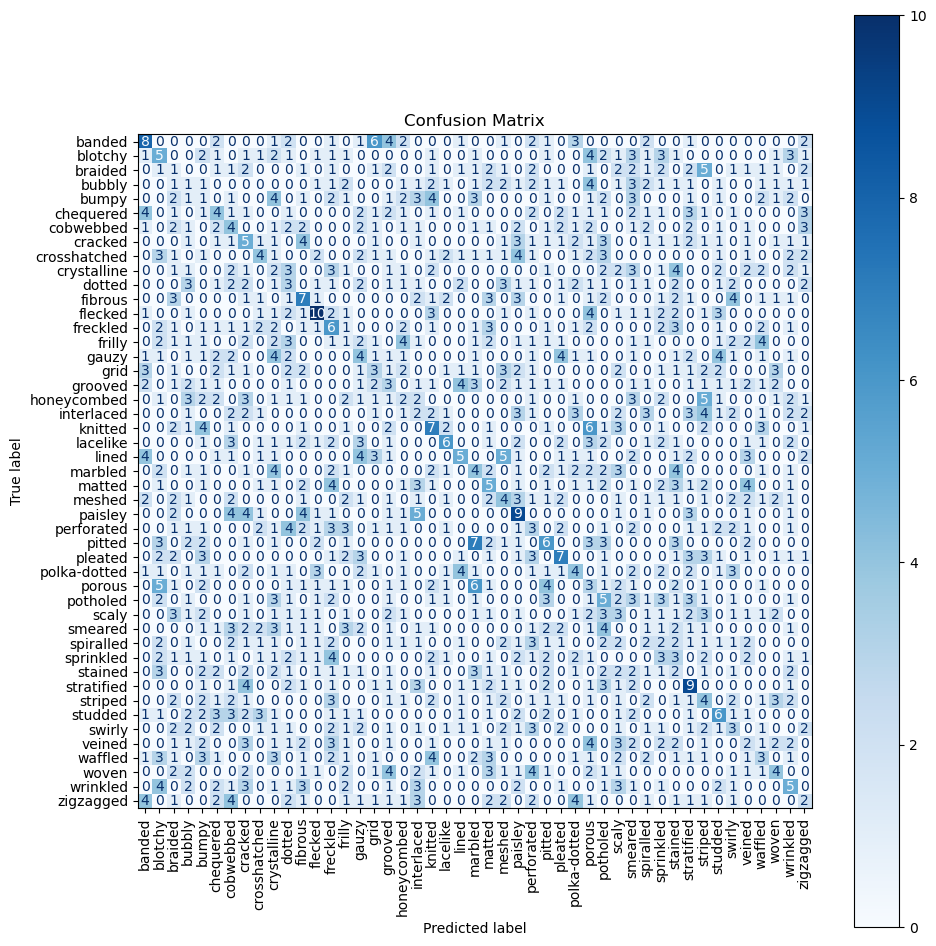

In [22]:
createConfusionMatrix(RI_model_rotBoth.y_pred, RI_model_rotBoth.y_test)

In [27]:
rotate_angles = [0, 30, 45, 60, 90, 120, 135, 150, 180]
RI_accuracy_list = {}
RI_model_list = {}

In [28]:
for angle in rotate_angles:
    print(f"Rotate Angle: {angle} deg")
    X_train, X_test, y_train, y_test = load_train_test_data(train_path='Data/DTD/train/', test_path='Data/DTD/test/', train_rotate_angle=0, test_rotate_angle=angle)
    model = LBP(rotation_invariant=True)
    model.fit(X_train, y_train)
    model.predict(X_test, y_test)
    RI_model_list[angle] = model
    acc = getAccuracy(model.y_pred, model.y_test)
    RI_accuracy_list[angle] = acc * 100
    print(f"Classification Accuracy: {acc * 100:.2f}%")
    print('-'*60)

Rotate Angle: 0 deg


Loading Test Images: 100%|██████████| 47/47 [00:13<00:00,  3.59it/s, Current Class=zigzagged]   
Rotataional Invariant | Extracting Train Features: 100%|██████████| 1880/1880 [00:18<00:00, 99.89it/s] 
Rotataional Invariant | Extracting Test Features: 100%|██████████| 1880/1880 [00:18<00:00, 103.35it/s]


Classification Accuracy: 10.69%
------------------------------------------------------------
Rotate Angle: 30 deg


Loading Test Images: 100%|██████████| 47/47 [00:17<00:00,  2.66it/s, Current Class=zigzagged]   
Rotataional Invariant | Extracting Train Features: 100%|██████████| 1880/1880 [00:19<00:00, 96.06it/s] 
Rotataional Invariant | Extracting Test Features: 100%|██████████| 1880/1880 [00:18<00:00, 102.10it/s]


Classification Accuracy: 3.46%
------------------------------------------------------------
Rotate Angle: 45 deg


...

Classification Accuracy: 3.03%
------------------------------------------------------------
Rotate Angle: 150 deg


Loading Test Images: 100%|██████████| 47/47 [00:16<00:00,  2.84it/s, Current Class=zigzagged]   
Rotataional Invariant | Extracting Train Features: 100%|██████████| 1880/1880 [00:18<00:00, 102.80it/s]
Rotataional Invariant | Extracting Test Features: 100%|██████████| 1880/1880 [00:17<00:00, 108.07it/s]


Classification Accuracy: 3.56%
------------------------------------------------------------
Rotate Angle: 180 deg


Loading Test Images: 100%|██████████| 47/47 [00:12<00:00,  3.69it/s, Current Class=zigzagged]   
Rotataional Invariant | Extracting Train Features: 100%|██████████| 1880/1880 [00:18<00:00, 103.27it/s]
Rotataional Invariant | Extracting Test Features: 100%|██████████| 1880/1880 [00:17<00:00, 105.46it/s]


Classification Accuracy: 10.69%
------------------------------------------------------------


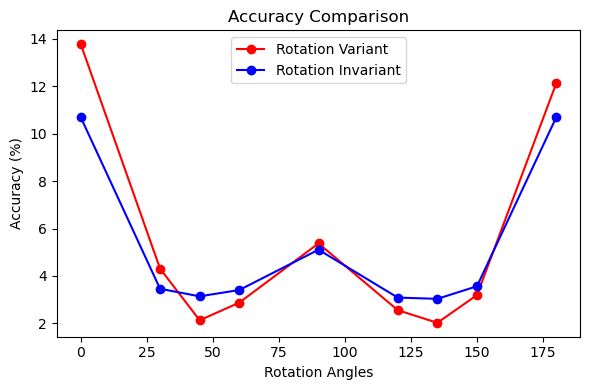

In [29]:
plt.figure(figsize=(6, 4))
plt.plot(rotate_angles, SM_accuracy_list.values(), color = 'r', marker = 'o', label = 'Rotation Variant')
plt.plot(rotate_angles, RI_accuracy_list.values(), color = 'b', marker = 'o', label = 'Rotation Invariant')
plt.xlabel('Rotation Angles')
plt.ylabel('Accuracy (%)')
plt.title("Accuracy Comparison")
plt.legend()
plt.tight_layout()
plt.show()

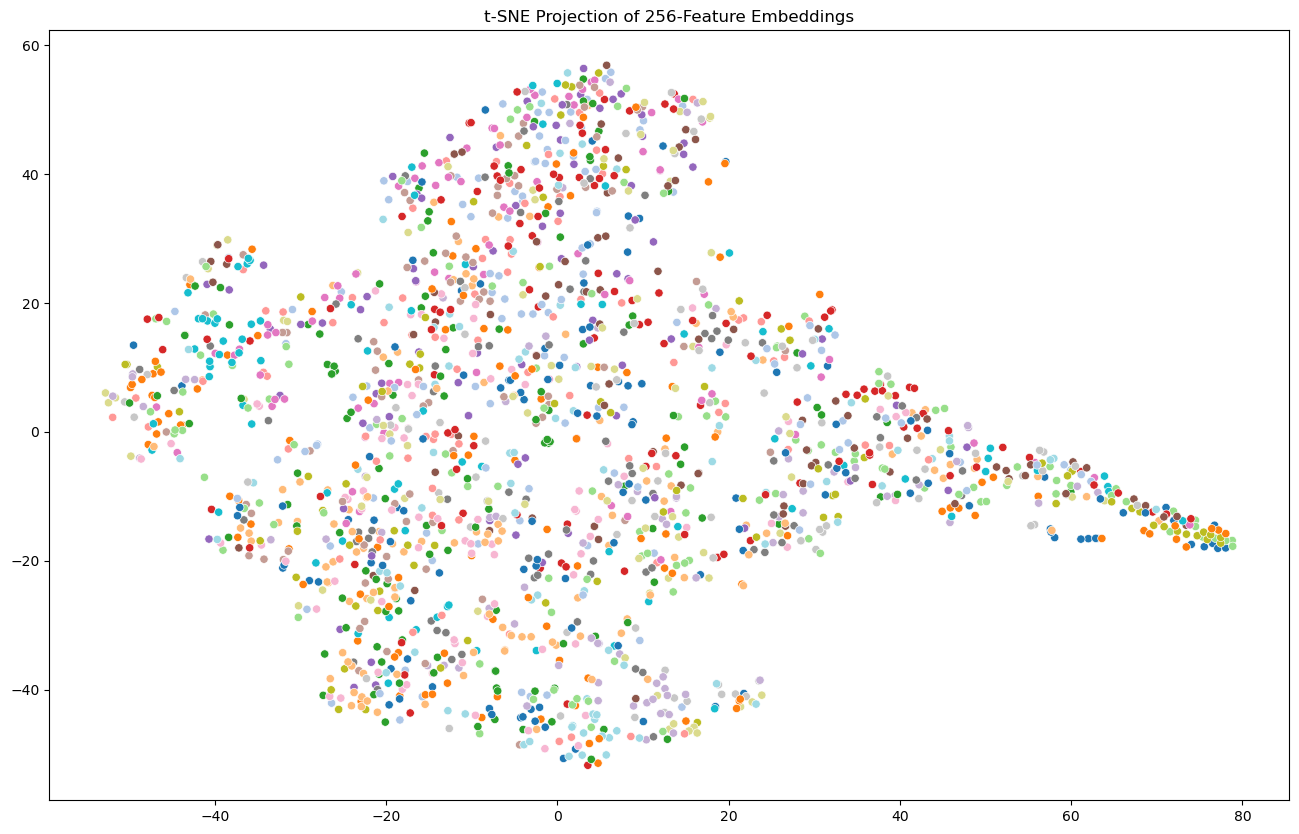

In [ ]:
# This is GEMINI generated code to check the plot to see how much overlap is there between the classes

import seaborn as sns
from sklearn.manifold import TSNE

X = simple_model.X_train
y = simple_model.y_train

tsne = TSNE(n_components=2, perplexity=30, max_iter=3000, random_state=42)
X_embedded = tsne.fit_transform(X)

plt.figure(figsize=(16, 10))
sns.scatterplot(
    x=X_embedded[:,0], 
    y=X_embedded[:,1], 
    hue=y, 
    palette="tab20",
    legend=False,
    alpha=1
)
plt.title("t-SNE Projection of 256-Feature Embeddings")
plt.show()

In [34]:
# We can see that the all the 47 classes are highly overlapping, and thus the reason why we are seeing such low accuracy

### Q1 again on a subset of classes

In [ ]:
Subset = 5
SM_sub_accuracy_list = {}
SM_sub_model_list = {}
RI_sub_accuracy_list = {}
RI_sub_model_list = {}

In [40]:
for angle in rotate_angles:
    print(f"Rotate Angle: {angle} deg")
    X_train, X_test, y_train, y_test = load_train_test_data(train_path='Data/DTD/train/', test_path='Data/DTD/test/', train_rotate_angle=0, test_rotate_angle=angle, n_class = Subset)

    model = LBP()
    model.fit(X_train, y_train)
    model.predict(X_test, y_test)
    SM_sub_model_list[angle] = model
    SM_acc = getAccuracy(model.y_pred, model.y_test)
    SM_sub_accuracy_list[angle] = SM_acc * 100

    rot_model = LBP(rotation_invariant=True)
    rot_model.fit(X_train, y_train)
    rot_model.predict(X_test, y_test)
    RI_sub_model_list[angle] = rot_model
    RI_acc = getAccuracy(rot_model.y_pred, rot_model.y_test)
    RI_sub_accuracy_list[angle] = RI_acc * 100

    print(f"Classification Accuracy: Standard Model - {SM_acc*100:.2f}% | Rotational Invariant Model - {RI_acc*100:.2f}%")
    print('-'*60)

Rotate Angle: 0 deg


Loading Test Images: 100%|██████████| 5/5 [00:01<00:00,  4.22it/s, Current Class=veined]   
Standard LBP | Extracting Train Features: 100%|██████████| 200/200 [00:01<00:00, 169.49it/s]
Standard LBP | Extracting Test Features: 100%|██████████| 200/200 [00:01<00:00, 175.25it/s]
Rotataional Invariant | Extracting Train Features: 100%|██████████| 200/200 [00:01<00:00, 153.40it/s]
Rotataional Invariant | Extracting Test Features: 100%|██████████| 200/200 [00:01<00:00, 165.49it/s]


Classification Accuracy: Standard Model - 41.50% | Rotational Invariant Model - 41.50%
------------------------------------------------------------
Rotate Angle: 30 deg


Loading Test Images: 100%|██████████| 5/5 [00:01<00:00,  3.19it/s, Current Class=sprinkled]
Standard LBP | Extracting Train Features: 100%|██████████| 200/200 [00:01<00:00, 183.01it/s]
Standard LBP | Extracting Test Features: 100%|██████████| 200/200 [00:01<00:00, 186.98it/s]
Rotataional Invariant | Extracting Train Features: 100%|██████████| 200/200 [00:01<00:00, 169.29it/s]
Rotataional Invariant | Extracting Test Features: 100%|██████████| 200/200 [00:01<00:00, 162.39it/s]


Classification Accuracy: Standard Model - 19.00% | Rotational Invariant Model - 20.50%
------------------------------------------------------------
Rotate Angle: 45 deg


...

Classification Accuracy: Standard Model - 21.50% | Rotational Invariant Model - 27.50%
------------------------------------------------------------
Rotate Angle: 150 deg


Loading Test Images: 100%|██████████| 5/5 [00:01<00:00,  2.80it/s, Current Class=stained]
Standard LBP | Extracting Train Features: 100%|██████████| 200/200 [00:01<00:00, 162.13it/s]
Standard LBP | Extracting Test Features: 100%|██████████| 200/200 [00:01<00:00, 159.81it/s]
Rotataional Invariant | Extracting Train Features: 100%|██████████| 200/200 [00:01<00:00, 154.31it/s]
Rotataional Invariant | Extracting Test Features: 100%|██████████| 200/200 [00:01<00:00, 153.74it/s]


Classification Accuracy: Standard Model - 27.50% | Rotational Invariant Model - 26.00%
------------------------------------------------------------
Rotate Angle: 180 deg


Loading Test Images: 100%|██████████| 5/5 [00:01<00:00,  4.50it/s, Current Class=woven]  
Standard LBP | Extracting Train Features: 100%|██████████| 200/200 [00:01<00:00, 174.84it/s]
Standard LBP | Extracting Test Features: 100%|██████████| 200/200 [00:01<00:00, 184.75it/s]
Rotataional Invariant | Extracting Train Features: 100%|██████████| 200/200 [00:01<00:00, 165.72it/s]
Rotataional Invariant | Extracting Test Features: 100%|██████████| 200/200 [00:01<00:00, 172.89it/s]

Classification Accuracy: Standard Model - 55.50% | Rotational Invariant Model - 58.00%
------------------------------------------------------------


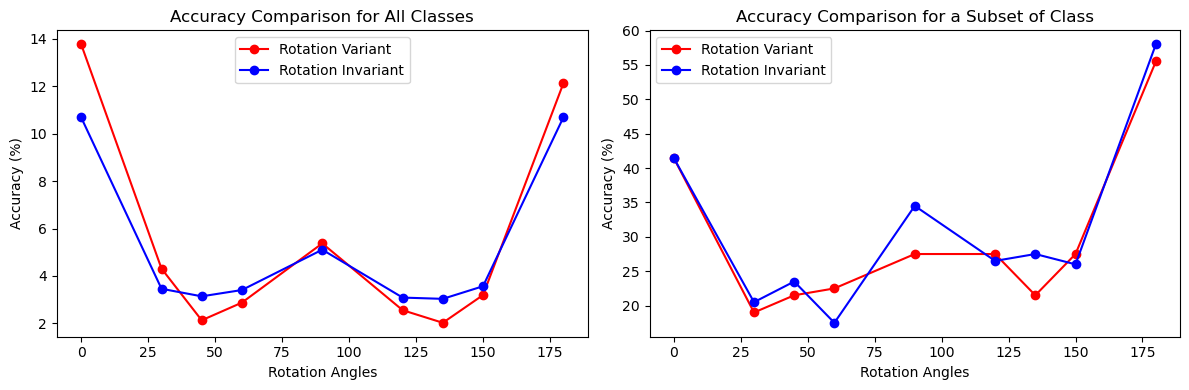

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rotate_angles, SM_accuracy_list.values(), color = 'r', marker = 'o', label = 'Rotation Variant')
axes[0].plot(rotate_angles, RI_accuracy_list.values(), color = 'b', marker = 'o', label = 'Rotation Invariant')
axes[0].set_xlabel('Rotation Angles')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title("Accuracy Comparison for All Classes")
axes[0].legend()
axes[1].plot(rotate_angles, SM_sub_accuracy_list.values(), color = 'r', marker = 'o', label = 'Rotation Variant')
axes[1].plot(rotate_angles, RI_sub_accuracy_list.values(), color = 'b', marker = 'o', label = 'Rotation Invariant')
axes[1].set_xlabel('Rotation Angles')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title("Accuracy Comparison for a Subset of Class")
axes[1].legend()
plt.tight_layout()
plt.show()

In [42]:
# 